<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Core Diagnostic 5 - Numerical Propagation
---

This notebook diagnoses the medium-independent numerical propagation utilities in `tpeanuts.core.numerical`: trajectory sampling, segment-wise matrix exponentials, composition, and accumulated evolution history. The automated checks live in `tpeanuts.core.numerical.test.test1_numerical_evolutor` and `tpeanuts.core.numerical.test.test2_numerical_geometry`.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: piecewise-constant numerical propagation |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Numerical-Geometry) | **Numerical Geometry**: sampling rules and trajectories |
| [4](#4.-Segment-Evolutors) | **Segment Evolutors**: local matrix exponentials |
| [5](#5.-Accumulated-Evolution) | **Accumulated Evolution**: history and convergence |
| [?](#6.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Piecewise-Constant Propagation

The numerical core approximates a continuous matter profile by splitting a trajectory into short segments. On each segment the electron density is sampled at a representative point and the Hamiltonian is treated as constant,

$$
S_j = \exp\left[-i H(n_e(x_j),E)\,\Delta x_j\right].
$$

The full evolution operator is the ordered product

$$
S_{\rm total}=S_N\cdots S_2S_1.
$$

### 0.2 Sampling Rules

For segment boundaries $x_i$ and $x_{i+1}$, the geometry helper supports three sampling rules:

$$
x_i^{\rm left}=x_i,
\qquad
x_i^{\rm right}=x_{i+1},
\qquad
x_i^{\rm midpoint}=\frac{x_i+x_{i+1}}{2}.
$$

The midpoint rule is the default and is usually the most accurate option for a piecewise-constant approximation at fixed segment count.

### 0.3 Evolution Coordinate

The numerical evolutor expects `dx_evolution`, the dimensionless increment used directly in $\exp(-iH\Delta x)$. Medium modules are responsible for converting their own geometry coordinate into this evolution coordinate before calling the numerical core.

### References

- C. Giunti and C. W. Kim, *Fundamentals of Neutrino Physics and Astrophysics*, Oxford University Press, 2007.
- J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, Cambridge University Press, 2020: time-evolution operator and matrix exponentials.

## 1. Libraries

All imports are centralized here. The diagnostic uses a synthetic smooth density profile so no external medium data are required.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import torch

from tpeanuts.core.common.probability import probability_transition
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.numerical.evolutor import evolutor_numerical, evolutor_numerical_segment
from tpeanuts.core.numerical.geometry import Trajectory, segment_sample_points
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

## 2. Paths and Configuration

### 2.1 Paths

Figures are saved under `diagnostic/core`, matching the notebook location below `notebooks/`.

In [2]:
config = load_notebook_config()
OUTPUT_DIR = config.output_dir("diagnostic", "core")
SHOW_PLOTS = config.show_plots

print(f"Repository root: {config.package_dir}")
print(f"Figure output directory: {OUTPUT_DIR}")

Repository root: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Figure output directory: v:\output\diagnostic\core


### 2.2 Configuration

The synthetic profile is smooth and positive. The path coordinate is already treated as the dimensionless evolution coordinate for this diagnostic.

**Expected results**: segment evolutors should be unitary, the accumulated history should start at identity, and increasing the segment count should make the final probability approach a stable value.

In [3]:
ctx = RuntimeContext.resolve(config.device, config.dtype)
CDTYPE = torch.complex128 if ctx.dtype == torch.float64 else torch.complex64
oscillation = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", context=ctx)
ENERGY_MEV = torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype)
PATH_END = torch.tensor(0.18, device=ctx.device, dtype=ctx.dtype)
N_SEGMENTS = 48


def density_profile(x):
    return 1.2 + 0.35 * torch.sin(2.0 * torch.pi * x / PATH_END) + 0.15 * x / PATH_END

print("energy [MeV]:", float(ENERGY_MEV))
print("path end:", float(PATH_END))
print("nominal segments:", N_SEGMENTS)

energy [MeV]: 1000.0
path end: 0.18
nominal segments: 48


### 2.3 Local Helpers

Small helpers build synthetic trajectories and compute a compact unitarity residual.

In [4]:
def build_trajectory(n_segments, *, method="midpoint"):
    x = torch.linspace(0.0, float(PATH_END), int(n_segments) + 1, device=ctx.device, dtype=ctx.dtype)
    dx = x[1:] - x[:-1]
    sample_x = segment_sample_points(x, method=method)
    return Trajectory(x=x, dx_evolution=dx, sample_x=sample_x, meta={"method": method, "n_segments": int(n_segments)})


def unitary_residual(U):
    eye = torch.eye(U.shape[-1], device=U.device, dtype=U.dtype)
    return torch.max(torch.abs(U.conj().transpose(-2, -1) @ U - eye), dim=-1).values.max(dim=-1).values

## 3. Numerical Geometry

### 3.1 Sampling Rules

This plot compares left, midpoint, and right sampling points on the same boundary grid.

**Expected results**: midpoint samples sit at segment centres, while left/right samples coincide with the corresponding segment endpoints.

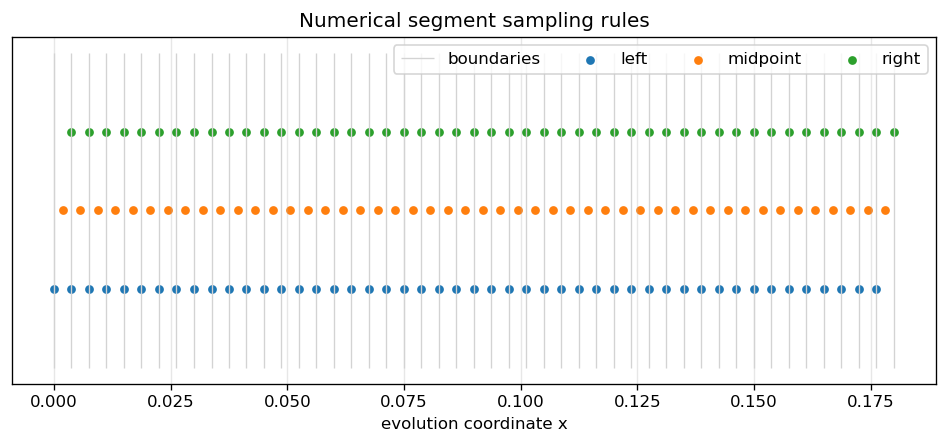

v:\output\diagnostic\core\diagnostic5_fig3_1_sampling_rules.png


In [5]:
trajectory_mid = build_trajectory(N_SEGMENTS, method="midpoint")
sample_left = segment_sample_points(trajectory_mid.x, method="left")
sample_mid = trajectory_mid.sample_x
sample_right = segment_sample_points(trajectory_mid.x, method="right")

fig, ax = plt.subplots(figsize=(8.0, 3.8))
ax.vlines(to_numpy(trajectory_mid.x), 0.0, 1.0, color="lightgray", lw=0.8, label="boundaries")
ax.scatter(to_numpy(sample_left), np.full(N_SEGMENTS, 0.25), s=18, label="left")
ax.scatter(to_numpy(sample_mid), np.full(N_SEGMENTS, 0.50), s=18, label="midpoint")
ax.scatter(to_numpy(sample_right), np.full(N_SEGMENTS, 0.75), s=18, label="right")
ax.set_xlabel("evolution coordinate x")
ax.set_yticks([])
ax.set_title("Numerical segment sampling rules")
ax.legend(ncol=4)
fig.tight_layout()
save_and_show("diagnostic5_fig3_1_sampling_rules.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.2 Sampled Density Profile

The numerical evolutor receives one density value per segment. Here the synthetic profile is sampled at the default midpoint locations.

**Expected results**: sampled values should follow the smooth profile without introducing negative densities.

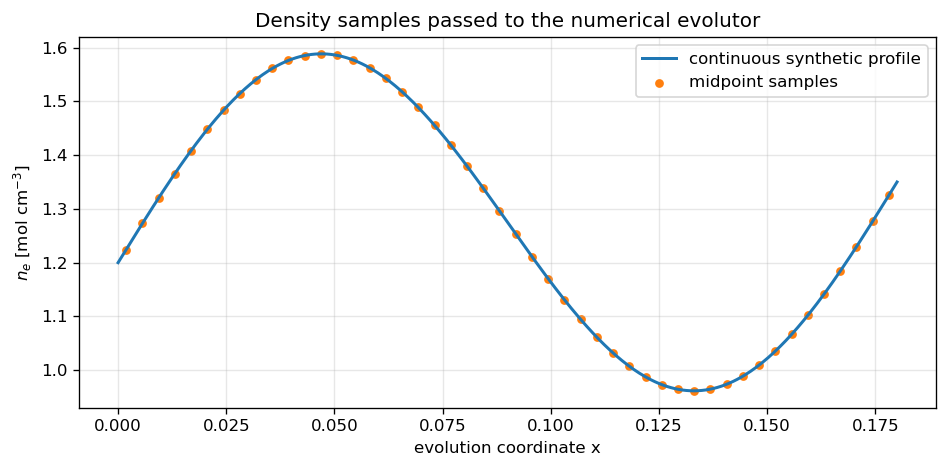

v:\output\diagnostic\core\diagnostic5_fig3_2_density_samples.png
min sampled density: 0.9616868768664888
max sampled density: 1.5883131231335113


In [6]:
x_dense = torch.linspace(0.0, float(PATH_END), 400, device=ctx.device, dtype=ctx.dtype)
n_dense = density_profile(x_dense)
n_samples = density_profile(trajectory_mid.sample_x)

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(to_numpy(x_dense), to_numpy(n_dense), lw=1.8, label="continuous synthetic profile")
ax.scatter(to_numpy(trajectory_mid.sample_x), to_numpy(n_samples), s=18, color="C1", label="midpoint samples")
ax.set_xlabel("evolution coordinate x")
ax.set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
ax.set_title("Density samples passed to the numerical evolutor")
ax.legend()
fig.tight_layout()
save_and_show("diagnostic5_fig3_2_density_samples.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("min sampled density:", float(n_samples.min()))
print("max sampled density:", float(n_samples.max()))

## 4. Segment Evolutors

### 4.1 Local Matrix Exponentials

Each sampled density and segment length produces one local matrix exponential.

**Expected results**: every local segment operator should be unitary up to floating-point precision.

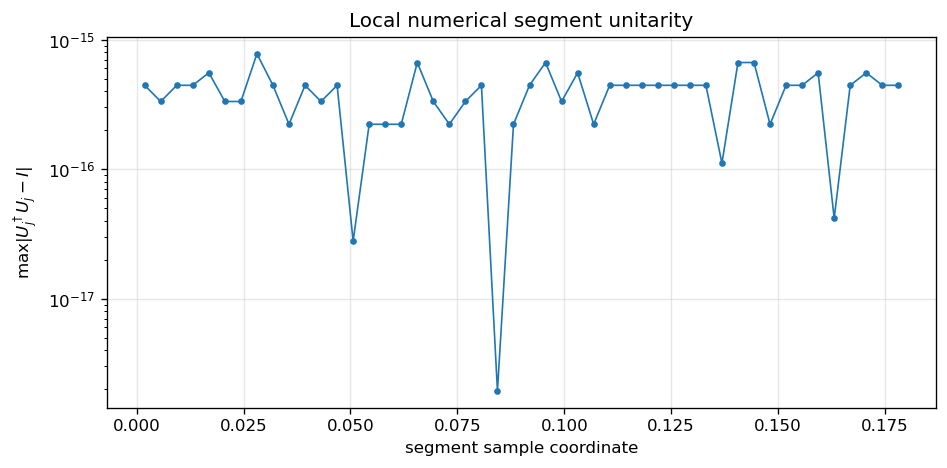

v:\output\diagnostic\core\diagnostic5_fig4_1_segment_unitarity.png
max segment unitarity residual: 7.771561172376096e-16


In [7]:
U_steps = evolutor_numerical_segment(
    oscillation,
    ENERGY_MEV,
    n_samples,
    trajectory_mid.dx_evolution,
    device=ctx.device,
    dtype=ctx.dtype,
)
segment_unitarity = unitary_residual(U_steps)

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.semilogy(to_numpy(trajectory_mid.sample_x), np.maximum(to_numpy(segment_unitarity), 1e-300), marker="o", ms=3.0, lw=1.0)
ax.set_xlabel("segment sample coordinate")
ax.set_ylabel(r"$\max|U_j^\dagger U_j-I|$")
ax.set_title("Local numerical segment unitarity")
fig.tight_layout()
save_and_show("diagnostic5_fig4_1_segment_unitarity.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("max segment unitarity residual:", float(segment_unitarity.max()))

### 4.2 Segment Transition Strength

The local transition probability $P(\nu_e\to\nu_\mu)$ per segment reflects both the local Hamiltonian and the small segment length.

**Expected results**: individual segment transition probabilities should be small for the short synthetic steps used here.

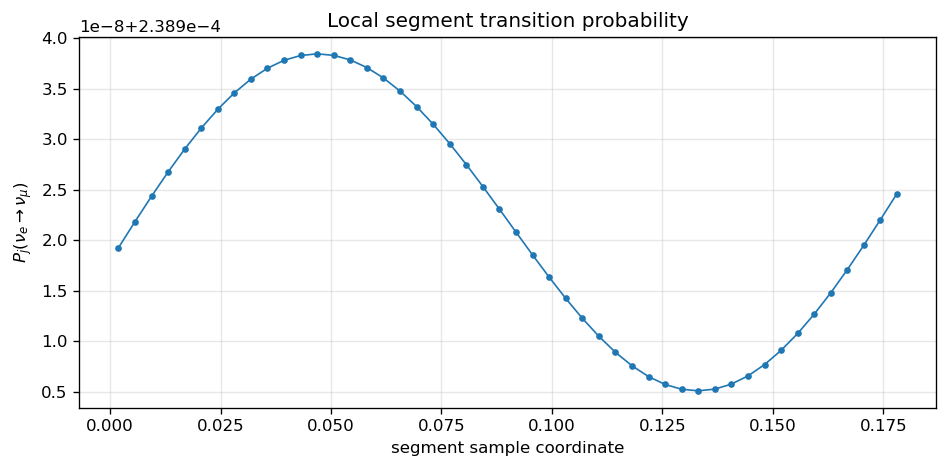

v:\output\diagnostic\core\diagnostic5_fig4_2_segment_transition.png
max local P(e->mu): 0.00023893845519545545


In [8]:
P_steps = probability_transition(U_steps)
P_emu_steps = P_steps[..., 1, 0]

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(to_numpy(trajectory_mid.sample_x), to_numpy(P_emu_steps), marker="o", ms=3.0, lw=1.0)
ax.set_xlabel("segment sample coordinate")
ax.set_ylabel(r"$P_j(\nu_e\to\nu_\mu)$")
ax.set_title("Local segment transition probability")
fig.tight_layout()
save_and_show("diagnostic5_fig4_2_segment_transition.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("max local P(e->mu):", float(P_emu_steps.max()))

## 5. Accumulated Evolution

### 5.1 Evolution History

With `return_history=True`, the numerical evolutor returns the accumulated operator after each segment, including the initial identity.

**Expected results**: the history has `N+1` operators; the first operator is identity, and the final one is the total evolutor.

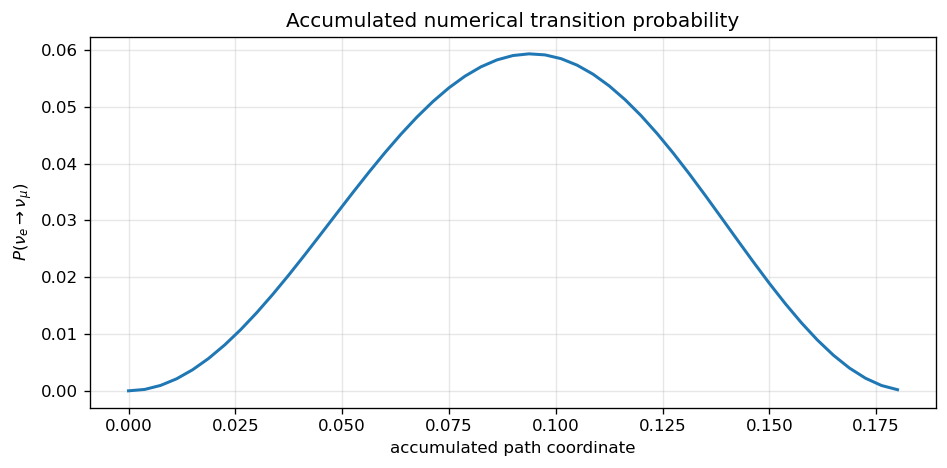

v:\output\diagnostic\core\diagnostic5_fig5_1_history_probability.png
history shape: (49, 3, 3)
initial identity residual: 0.0
final direct residual: 5.551115123125783e-16


In [9]:
history = evolutor_numerical(
    oscillation,
    ENERGY_MEV,
    n_samples,
    trajectory_mid.dx_evolution,
    return_history=True,
    device=ctx.device,
    dtype=ctx.dtype,
)
P_history = probability_transition(history)
P_emu_history = P_history[..., 1, 0]
identity_residual = torch.max(torch.abs(history[0] - torch.eye(3, device=ctx.device, dtype=CDTYPE)))
final_direct = evolutor_numerical(
    oscillation,
    ENERGY_MEV,
    n_samples,
    trajectory_mid.dx_evolution,
    device=ctx.device,
    dtype=ctx.dtype,
)
final_residual = torch.max(torch.abs(history[-1] - final_direct))

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(to_numpy(trajectory_mid.x), to_numpy(P_emu_history), lw=1.8)
ax.set_xlabel("accumulated path coordinate")
ax.set_ylabel(r"$P(\nu_e\to\nu_\mu)$")
ax.set_title("Accumulated numerical transition probability")
fig.tight_layout()
save_and_show("diagnostic5_fig5_1_history_probability.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("history shape:", tuple(history.shape))
print("initial identity residual:", float(identity_residual))
print("final direct residual:", float(final_residual))

### 5.2 Segment-Count Convergence

The same smooth density profile is propagated with increasing segment counts. This provides a compact convergence diagnostic for the piecewise-constant approximation.

**Expected results**: the final transition probability should approach a stable value as the number of segments increases.

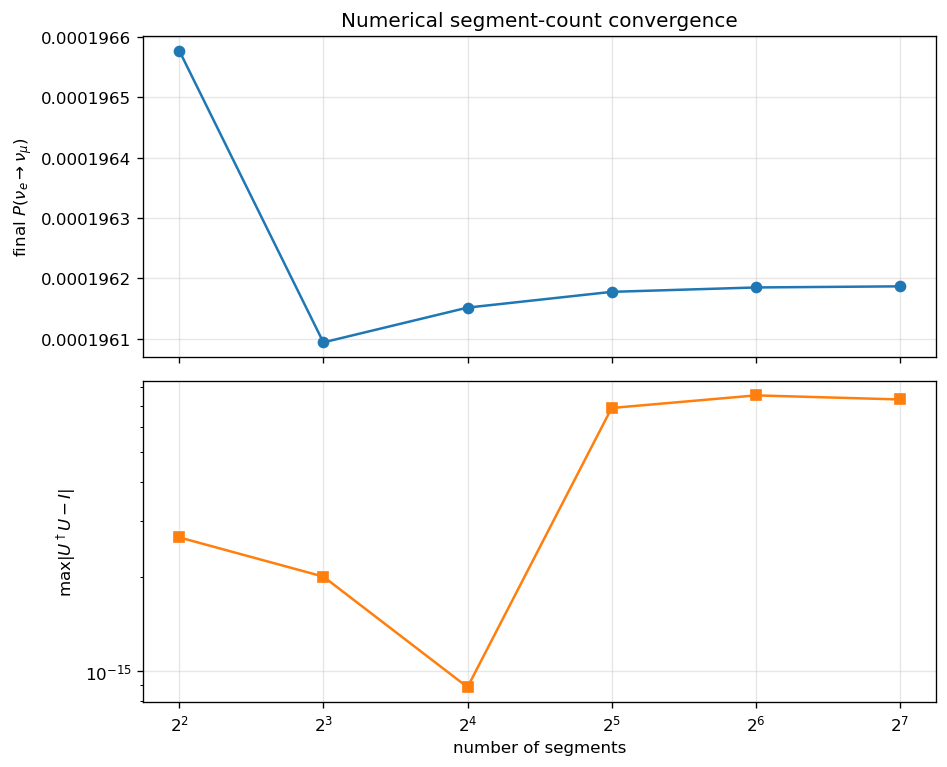

v:\output\diagnostic\core\diagnostic5_fig5_2_segment_convergence.png
final probabilities: [0.0001965770588406696, 0.00019609413743447654, 0.00019615166984698342, 0.00019617775550123882, 0.00019618501793733657, 0.00019618688001520396]
unitarity residuals: [2.6645352591003757e-15, 1.9984014443252818e-15, 8.881784197001252e-16, 6.8833827526759706e-15, 7.549516567451064e-15, 7.327471962526033e-15]


In [10]:
segment_counts = [4, 8, 16, 32, 64, 128]
final_pemu = []
max_unitarity = []
for n in segment_counts:
    traj = build_trajectory(n, method="midpoint")
    n_sample = density_profile(traj.sample_x)
    U = evolutor_numerical(oscillation, ENERGY_MEV, n_sample, traj.dx_evolution, device=ctx.device, dtype=ctx.dtype)
    P = probability_transition(U)
    final_pemu.append(float(P[1, 0].detach().cpu()))
    max_unitarity.append(float(unitary_residual(U).detach().cpu()))

fig, (ax_p, ax_u) = plt.subplots(2, 1, figsize=(8.0, 6.5), sharex=True)
ax_p.plot(segment_counts, final_pemu, marker="o")
ax_p.set_xscale("log", base=2)
ax_p.set_ylabel(r"final $P(\nu_e\to\nu_\mu)$")
ax_p.set_title("Numerical segment-count convergence")
ax_u.semilogy(segment_counts, np.maximum(max_unitarity, 1e-300), marker="s", color="C1")
ax_u.set_xlabel("number of segments")
ax_u.set_ylabel(r"$\max|U^\dagger U-I|$")
fig.tight_layout()
save_and_show("diagnostic5_fig5_2_segment_convergence.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
print("final probabilities:", final_pemu)
print("unitarity residuals:", max_unitarity)

## 6. Summary

The numerical core is a medium-independent piecewise-constant propagator. Geometry modules provide boundary coordinates, dimensionless segment increments, and density sample points. The numerical evolutor then builds one matrix exponential per segment and composes the resulting operators in propagation order.

The diagnostics verify the main invariants: sampling rules are explicit, segment operators are unitary, the accumulated history starts at identity and ends at the final operator, and increasing the number of segments produces a stable transition probability for the smooth synthetic density profile.